# Quais dos Planos são mais Rentáveis

Este projeto tem como objetivo realizar uma analise de dados na empresa Megaline e poder recolher informações pelos dados da empresa e responder perguntas como:Qual dos planos da empresa é mais rentável e porque é mais rentavel.

## Iniciação

Todo o projeto de analise de dados parte de um ponto, e este é o ponto, aqui será feita a importação das bibliotecas e usada a biblioteca pandas para importar os dados para um objeto dataframe que tornará a manipulação de grandes quantidades de dados viavél. Os conjuntos de dados enviados pela empresa são: megaline_calls, megaline_internet.csv, megaline_messages.csv, megaline_plans.csv e megaline_users.csv.

__Carregando Bibliotecas Necessarias__

Na celula abaixo são importadas as bibliotecas para manipulação de grandes conjuntos de dados, para realizar calculos e também bibliotecas para criar graficos de visualização usando uma fonte de dados.


In [243]:
#Carregando todas as bibliotecas

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import stats as st


### Carregando os dados

__Carregando os dados de csv para dataframes__

In [183]:
#Tirando os arquivos do csv para dataframes
df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')
df_users = pd.read_csv('/datasets/megaline_users.csv')

### Exploração dos dados iniciais

Os conjuntos de dados contêm os seguintes campos:

A tabela users (dados sobre usuários):
- **user_id** — identificação do usuário
- **first_name** — nome do usuário
- **last_name** — último sobrenome do usuário
- __age__ — idade do usuário (em anos)
- **reg_date** — data da inscrição (dd, mm, aa)
- **churn_date** — a data que o usuário parou de usar o serviço (se o valor for ausente, o plano estava sendo usado quando esse dado foi gerado)
- __city__ — cidade de residência do usuário
- __plan__ — nome do plano

A tabela calls (dados sobre as chamadas):
- __id__ — identificador de chamada unívoco
- **call_date** — data da chamada
- __duration__— duração da chamada (em minutos)
- **user_id**— o identificador do usuário que faz a chamada

A tabela messages (dados nas mensagens de texto):
- __id__ — identificador unívoco de mensagem de textos
- **message_date** — data da mensagem de texto
- **user_id** — o identificador do usuário que envia a mensagem de texto

A tabela internet (dados sobre sessões web):
- __id__ — identificador de sessão unívoco
- **mb_used** — o volume de dados gasto durante a sessão ( em megabytes)
- **session_date** — data da sessão web
- **user_id** — identificador do usuário

A tabela plans(dados sobre os planos):
- **plan_name** — o nome do plano de chamadas
- **usd_monthly_fee** — preço mensal em dólares dos EUA
- **minutes_included** — pacote de minutos mensal
- **messages_included** — pacote de mensagens de texto mensal
- **mb_per_month_included** — pacote de volume de dados (em megabytes)
- **usd_per_minute** — preço por minuto depois de exceder o limite do pacote (por exemplo, se o pacote inclui 100 minutos, o primeiro minuto excedente será cobrado)
- **usd_per_message** — preço por mensagem de texto depois de exceder o limite do pacote
- **usd_per_gb** — preço por gigabyte extra de dados após exceder o limite do pacote (1 GB = 1024 megabytes)

Imprimindo informações resumidas de cada dataframe.

In [184]:
#Imprimindo informações gerais/resumidas sobre o Dataframe
dfs = {'calls':df_calls, 'internet':df_internet, 'messages':df_messages, 'plans':df_plans, 'users':df_users}

for dataframe in dfs:
    print(f'Dataframe: {dataframe} info:')
    dfs[dataframe].info()
    print()

Dataframe: calls info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB

Dataframe: internet info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB

Dataframe: messages info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to

Imprimindo as dez(10) primeiras linhas de cada Dataframe.

In [185]:
for dataframe in dfs:
    print(f'Dataframe:{dataframe} dez primeiras linhas:')
    print(dfs[dataframe].head(10))
    print()

Dataframe:calls dez primeiras linhas:
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
5  1000_388     1000  2018-12-31      2.20
6  1000_510     1000  2018-12-27      5.75
7  1000_521     1000  2018-12-28     14.18
8  1000_530     1000  2018-12-28      5.77
9  1000_544     1000  2018-12-26      4.40

Dataframe:internet dez primeiras linhas:
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1

__Conclusões e Próximos passos__

Depois de feita esta pequena investigação dos nossos conjuntos de dados é possivel verificar que felizmente os nossos dados estão muito bem no que toca os valores ausentes e ja estão coerentes os nomes das colunas, porém as colunas id nos dataframes df_calls, df_internet e df_messages utilizam um tipo de dados dificil de lidar e também o id do usuario acoplado com o id das calls, internet e messages, seria muito conveniente converter para tipo de dados inteiro e armazenar apenas os seus ids sem o id do usuario visto que ja existe uma coluna user_id.




## Resolvendo os tipos de dados Inviaveis

Entre os dados presentes nos nossos conjuntos de dados será necessário corrigir as colunas de id para inteiro e as de data de tipo 'object' para 'datetime'


### Mundando Ids para inteiro

__Dataframe calls__

In [186]:
def split_ids(row):
    id = row['id']
    return int(id.split('_')[1])


df_calls['id'] = df_calls.apply(split_ids, axis=1)

__Dataframe internet__

In [187]:
df_internet['id'] = df_internet.apply(split_ids, axis=1)

__Dataframe messages__

In [188]:
df_messages['id'] = df_messages.apply(split_ids, axis=1)

### Mudando datas para datetime

__Dataframe calls__

In [189]:

df_calls['call_date'] = df_calls.astype({'call_date': 'datetime64[ns]'})['call_date']

__Dataframe internet__

In [190]:

df_internet['session_date'] = df_internet.astype({'session_date': 'datetime64[ns]'})['session_date']

__Dataframe messages__

In [191]:

df_messages['message_date'] =  df_messages.astype({'message_date': 'datetime64[ns]'})['message_date']

__Dataframe users__

In [192]:
#coluna reg_date
df_users['reg_date'] = df_users.astype({'reg_date': 'datetime64[ns]'})['reg_date']

#coluna churn_date
df_users['churn_date'] = df_users.astype({'churn_date': 'datetime64[ns]'})['churn_date']

### Gerando Informações dos Dados



**Criando coluna mes em df_calls**

In [193]:
df_calls['mes'] = df_calls['call_date'].dt.month

__Quantidade de chamadas para cada usuario__

In [194]:
# df_users['calls']
def calc_qtd_chamadas(row):
    user = row['user_id']
    return int(df_calls[df_calls['user_id'] == user].count()[0])

df_users['qtd_calls'] = df_users.apply(calc_qtd_chamadas, axis=1)


__Minutos usados por mês__

In [195]:
def calc_monthly_usage(row):
    user = row['user_id']    
    return math.ceil(df_calls[df_calls['user_id'] == user]['duration'].sum())
    
df_users['mins_total'] = df_users.apply(calc_monthly_usage, axis=1)
df_users['monthly_mins'] = df_users.mins_total / 12


__Mensagens enviadas por mês__

In [197]:
def calc_monthly_messages(row):
    user = row['user_id']
    return int(df_messages[df_messages['user_id'] == user].count()[0])

df_users['qtd_messages'] = df_users.apply(calc_monthly_messages, axis=1)
df_users['qtd_monthly_messages'] = (df_users.qtd_messages / 12).astype({'qtd_messages':'int'})


__Volume de dados por mês__

In [201]:
def calc_internet_monthly_usage(row):
    user = row['user_id']
    return int(df_internet[df_internet['user_id'] == user]['mb_used'].sum())
df_users['internet_total_usage'] = df_users.apply(calc_internet_monthly_usage, axis=1)
df_users['monthly_internet_usage'] =( df_users.internet_total_usage / 12).astype({'internet_total_usage':'int'})


__Receita Mensal__

Esta função 'calc_receita_mensal' calcula a receita mensal de um usuario e retorna ela. Irei aplicar a função para todas as linhas do conjunto de dados dos usuarios.

In [212]:

def calc_receita_mensal(row):
    user = row['user_id']
    total_calls = row['mins_total']
    qtd_messages = row['qtd_messages']
    internet_usage = row['internet_total_usage']
    plan = row['plan']
    cost_calls = 0
    cost_messages= 0
    cost_internet = 0
    monthly_cost = 0
    if plan == 'surf':
        if total_calls < 1:
            total_calls = 1

        total_calls = total_calls - 500
        qtd_messages = qtd_messages - 50
        internet_usage = internet_usage - 15360
        if (internet_usage / 1024) < 1:
            internet_usage = 1
        else:
            internet_usage = math.ceil(internet_usage / 1024)
            
        cost_calls = total_calls * 0.03
        cost_messages = qtd_messages * 0.03
        cost_internet = internet_usage * 10
        monthly_cost = cost_calls + cost_messages + cost_internet
        
    else:
        if total_calls < 1:
            total_calls = 1
        total_calls = total_calls - 3000
        qtd_messages = qtd_messages - 1000
        internet_usage = internet_usage - 30720
        if (internet_usage / 1024) < 1:
            internet_usage = 1
        else:
            internet_usage = math.ceil(internet_usage / 1024)
        
        cost_calls = total_calls * 0.01
        cost_messages = qtd_messages * 0.01
        cost_internet = internet_usage * 7
        monthly_cost = cost_calls + cost_messages + cost_internet
    if monthly_cost < 0.00 :
        return 0.00
    return monthly_cost
    
    
df_users['receita_mensal'] = df_users.apply(calc_receita_mensal, axis=1)

### Análise dos Dados

**Calculando os valores atipicos dos dados**

A celula abaixo contem a declaração de duas funções que irão filtrar os valores atípicos e retornar um dataframe sem valores atipicos da coluna passada por parametros.

In [227]:
#Vou criar uma função que calcula os limites superiores e inferiores por meio da quartiz
#Esta função irá ser usada para filtrar os dados que são incomuns
def remove_outliers(column):
    q1 = df_users[column].quantile(.25)
    q3 = df_users[column].quantile(.75)
    iqr = q3 - q1
    lim_inf = q1 - (1.5*iqr)
    lim_sup = q3 + (1.5*iqr)
    df_filtered = df_users.query(column+ '> @lim_inf and '+column+' < @lim_sup')
    return df_filtered

def remove_outliers_var(df, column):
    q1 = df[column].quantile(.25)
    q3 = df[column].quantile(.75)
    iqr = q3 - q1
    lim_inf = q1 - (1.5*iqr)
    lim_sup = q3 + (1.5*iqr)
    df_filtered = df.query(column+ '> @lim_inf and '+column+' < @lim_sup')
    return df_filtered
    

__Criando dataframe filtrado__

Será interessante remover os valores atípicos antes de realizar a analise de dados.

In [229]:
nonoutliers_df_users = remove_outliers('monthly_mins')

nonoutliers_df_users = remove_outliers_var(nonoutliers_df_users,'qtd_monthly_messages')

nonoutliers_df_users = remove_outliers_var(nonoutliers_df_users,'monthly_internet_usage')


__Calculando a media, variância, e o desvio padrão__

Media das colunas duracao da chamada por mes, mensagens por mes e uso de internet por mes

In [230]:
mean_nonoutliers_calls = nonoutliers_df_users.monthly_mins.mean()

mean_nonoutliers_messages = nonoutliers_df_users.qtd_monthly_messages.mean()

mean_nonoutliers_internet = nonoutliers_df_users.monthly_internet_usage.mean()



Calculando a variancia e o desvio padrao para as mesmas colunas.

In [237]:
#Variancia de monthly_mins 
var_monthly_mins = np.var(nonoutliers_df_users.monthly_mins)

#Variancia de monthly_messages
var_monthly_messages = np.var(nonoutliers_df_users.qtd_monthly_messages)

#Variancia de monthly_internet
var_monthly_internet = np.var(nonoutliers_df_users.monthly_internet_usage)

#Desvio padrao de monthly_mins
std_monthly_mins = np.std(nonoutliers_df_users.monthly_mins)

#Desvio padrao de monthly_messages
std_monthly_messages = np.std(nonoutliers_df_users.qtd_monthly_messages)

#Desvio padrao de monthly_internet
std_monthly_internet_usage = np.std(nonoutliers_df_users.monthly_internet_usage)


__Visualizando o conjunto de dados filtrados__

 Aqui é apresentado o grafico para a duração das chamadas feitas por mês.

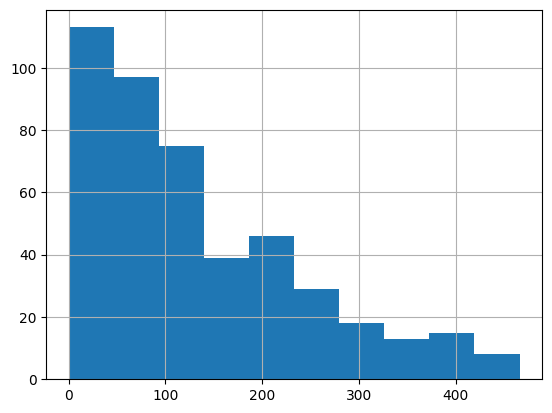

In [238]:
#monthly_mins
nonoutliers_df_users.monthly_mins.hist()
plt.show()

A celula abaixo apresenta o grafico das mensagens enviadas por mês.

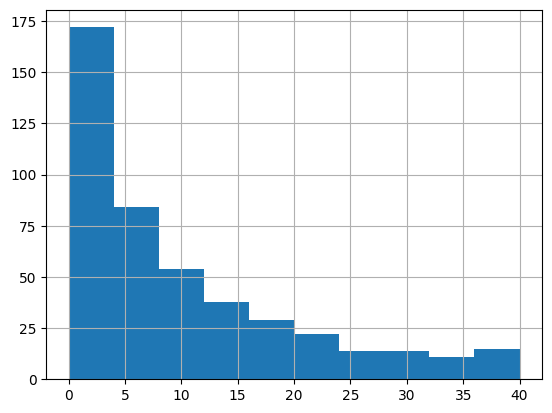

In [239]:
#monthly_mins
nonoutliers_df_users.qtd_monthly_messages.hist()
plt.show()

Abaixo é apresentado o grafico do consumo de dados por mês.

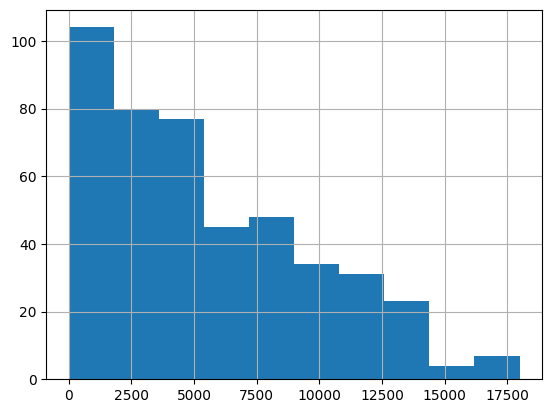

In [240]:
#monthly_mins
nonoutliers_df_users.monthly_internet_usage.hist()
plt.show()

### Teste de Hipóteses

#### Primeiro Teste: a  receita média dos usuarios do plano ultimate e surf são diferentes?

__Estabelecendo um nivel critico de significancia estatística__

In [250]:
alpha = 0.05 

__Criando um dataframe para os usuarios de plano surf e outro para os do plano ultimate__

In [266]:
users_surf = nonoutliers_df_users.query('plan == "surf"')


users_ultimate = nonoutliers_df_users.query('plan == "ultimate"')

__Comparando a igualdade das médias dos dois conjuntos__

In [267]:
results = st.ttest_ind(users_surf.receita_mensal, users_ultimate.receita_mensal)

__Analizando o resultado do teste de hipótese__

In [268]:
if results.pvalue < alpha:
    print("A receita média dos usuarios dos dois planos são diferentes")
else:
    print("A receita média dos usuarios dos dois planos não são diferentes")


A receita média dos usuarios dos dois planos são diferentes


#### Segundo Teste: a  receita média dos usuarios da area NY-NJ é diferente dos usuarios de outras regiões?

__Estabelecendo um nivel critico de significancia estatística__

In [250]:
alpha = 0.05 

__Criando um dataframe para os usuarios da região NY-NJ e outro para as restantes regiões__

In [278]:
users_ny_nj = nonoutliers_df_users.query('"New York-Newark-Jersey City, NY-NJ-PA MSA" == city')


users_other_regions = nonoutliers_df_users.query('"New York-Newark-Jersey City, NY-NJ-PA MSA" != city')

__Comparando a igualdade das médias dos dois conjuntos__

In [281]:
results_test2 = st.ttest_ind(users_ny_nj.receita_mensal, users_other_regions.receita_mensal)

__Analizando o resultado do teste de hipótese__

In [282]:
if results_test2.pvalue < alpha:
    print("A receita média dos usuarios tanto da região NY-NJ como de todas outras regiões é diferente")
else:
    print("A receita média dos usuarios da região NY-NJ  nâo são diferentes dos usuarios de outras regiões")


A receita média dos usuarios da região NY-NJ  nâo são diferentes dos usuarios de outras regiões


**Conclusões**

A analise de estatistica e os testes de hipoteses permitiram-nos encontrar informações que indicam que a receita média dos usuarios dos dois planos tanto o 'surf' como  o 'ultimate' são diferentes. Para encontrar este resultado criei conjunto de dados para usuarios do plano surf e conjunto para usuarios do plano surf e fiz um teste de igualdade das medias das colunas receita mensal destes dois conjuntos.

No segundo teste usei a mesma metodologia, porém não usei os planos mas as cidades ou regiões separei as os usuarios da região NY-NJ e os usuarios de todas as outras regiões e fiz o teste de igualdade da receita média dos dois conjuntos e o resultado foi que a receita média da região NY-NJ é igual a receita média de todas as outras regiões 

## Conclusão geral

Este projeto de analise de dados permitiu perceber bastante informações sobre os planos da empresa Megaline, com base nesta informação seria interessante aplicar estratégias de marketing diferentes para cada plano, pois os usuarios do plano surf são significativamente diferentes aos usuarios do plano ultimate.



